In [16]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np

In [3]:
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print('length of dataset in characters: ', len(text))

length of dataset in characters:  1115393


In [ ]:
print(text[:1000])

In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [7]:
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [8]:
a = encode('hii there')
print(a)
b = decode(a)
print(b)

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [9]:
# gpt-2 sub-word tokenizer just as an example

import tiktoken

enc = tiktoken.get_encoding('gpt2')
enc.n_vocab

a = enc.encode('hii there')
print(a)
b = enc.decode(a)
print(b)

[71, 4178, 612]
hii there


In [ ]:
# encode the whole text and wrap it into a pytroch tensor

data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000])

In [11]:
# split the data into training and validation sets

n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]

In [12]:
block_size = 8 # could be named context or whatever
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [13]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f'when input is {context}, the target is {target}')

when input is tensor([18]), the target is 47
when input is tensor([18, 47]), the target is 56
when input is tensor([18, 47, 56]), the target is 57
when input is tensor([18, 47, 56, 57]), the target is 58
when input is tensor([18, 47, 56, 57, 58]), the target is 1
when input is tensor([18, 47, 56, 57, 58,  1]), the target is 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]), the target is 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]), the target is 58


In [14]:
# creating the batching process

torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will be processed in parallel?
block_size = 8 # what is the maximum context langth for predictions?

def get_batch(split):
    # generate a small batch of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - batch_size, (batch_size,)) # batch_size = 4 random ints between 0 -> len(data) - batch_size
    x = torch.stack([data[i:i+block_size] for i in ix]) # torch.stack creates (batch_size, block_size)-dim tensor from random ix pos
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1].tolist()
        target = yb[b, t]
        print(f'when input is {context}, the target is: {target}')
    break

inputs:
torch.Size([4, 8])
tensor([[52, 53, 58,  1, 53, 59, 56,  1],
        [ 1, 41, 53, 51, 43, 57,  1, 58],
        [61, 39, 49, 43,  6,  1, 39, 52],
        [ 1, 42, 53, 58, 46,  1, 51, 63]])
targets:
torch.Size([4, 8])
tensor([[53, 58,  1, 53, 59, 56,  1, 56],
        [41, 53, 51, 43, 57,  1, 58, 46],
        [39, 49, 43,  6,  1, 39, 52, 42],
        [42, 53, 58, 46,  1, 51, 63,  1]])
when input is [52], the target is: 53
when input is [52, 53], the target is: 58
when input is [52, 53, 58], the target is: 1
when input is [52, 53, 58, 1], the target is: 53
when input is [52, 53, 58, 1, 53], the target is: 59
when input is [52, 53, 58, 1, 53, 59], the target is: 56
when input is [52, 53, 58, 1, 53, 59, 56], the target is: 1
when input is [52, 53, 58, 1, 53, 59, 56, 1], the target is: 56


In [42]:
n_embd = 32

l = nn.Embedding(vocab_size, n_embd)
m = nn.Embedding(block_size, n_embd)

B, T = xb.shape

l1 = l(xb)
m1 = m(torch.arange(T))
l1.shape, m1.shape
(a := l1+m1).shape
m1.shape
xb.shape, l1.shape

(torch.Size([4, 8]), torch.Size([4, 8, 32]))

In [65]:
n_embd = 32
class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size) # language modeling head

    def forward(self, idx, targets=None):
        B, T = idx.shape
        # idx and targets are both (B, T) tensors of integers
        token_emb = self.token_embedding_table(idx) # (B, T, C)
        pos_emb = self.position_embedding_table(torch.arange(T)) # (T, C)
        x = token_emb + pos_emb
        logits = self.lm_head(x) # (B, T, vocab_size)

        if targets == None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # could be logits.view(-1, C)
            targets = targets.view(B*T) # could be targets.view(-1)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
    
m = BigramLanguageModel()
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

# test output generation


torch.Size([256, 65])
tensor(4.4756, grad_fn=<NllLossBackward0>)


In [18]:
# create a ptrorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [19]:
# training loop
batch_size = 32
for steps in range(10000):
    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

2.487516164779663


In [ ]:
help(m)

In [66]:
[i for i in m.children()]

[Embedding(65, 32),
 Embedding(8, 32),
 Linear(in_features=32, out_features=65, bias=True)]

In [22]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


M:
IUSh t,
F th he d ke alved.
Thupld, cipbll t
I: ir w, ishe sie hend lor ito'l an e

I:
Gochosen ea ar btain IShillind wast, plt t wadyotl
I bel qunganonoth he m he de avellis knt, tond soran:

WI he toust are bott oe n t s d je hid t his IAces I my ig t
Ril'swoll e pupy IUSard acendenothiqu heamer te
Wht s

MI wect!-lltherotheve t fe;
WAnd py;

PO t s ld tathat, ir V
IO thesecin teot tit ado ilorer.
Ply, d'stacoes, ld omat mealellly yererer EMEvesas ie IZEd pave mautoofareanerllleyomerer but?


## The mathematical trick for self attention

In [55]:
# consider the following toy example:

torch.manual_seed(42)
B, T, C = 4, 8, 2 # batch, time , channels
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

In [50]:
# we want x[b, t] = mean_{i<=t} x[b, i]
# the loop is filling the xbow matrix with average values of previous context windows of matrix x
# i.e. xbow[0, 5] = average of prev[0, :5+1]. note that torch.mean(xprev, 0) averages over the first
# dim -> averaging horizontally, so we're averaging features over time, not over all features of
# a single time step. But notice also, that this is not an efficient way of averaging.

xbow = torch.zeros((B, T, C)) # bow = bag of words
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1] # (t, C)
        xbow[b, t] = torch.mean(xprev, 0)

In [25]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [26]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [ ]:
# now this is the trick:

torch.manual_seed(42)
a = torch.ones(3,3)
b = torch.randint(0, 10, (3,2)).float()
c = a @ b
print('a=')
print(a)
print('---')
print('b=')
print(b)
print('---')
print('c=')
print(c)

a=
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
---
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
---
c=
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


In [39]:
# the trick is to use torch.tril (triangular maybe?)
torch.tril(a)

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [44]:
torch.sum(torch.tril(a), 1, keepdim=True)

tensor([[1.],
        [2.],
        [3.]])

In [ ]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))
# notice how torch.sum(...) sums the feature axis to 1, and thereby you can calculate the mean by
# matmultiplying the matrices
a = a / torch.sum(a, 1, keepdim=True) 
b = torch.randint(0, 10, (3,2)).float()
c = a @ b
print('a=')
print(a)
print('---')
print('b=')
print(b)
print('---')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
---
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
---
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [56]:
# first iteration of the trick:

xbow = torch.zeros((B, T, C)) # bow = bag of words
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1] # (t, C)
        xbow[b, t] = torch.mean(xprev, 0)

wei = torch.tril(torch.ones(T, T)) # wei = weights
wei = wei / wei.sum(1, keepdim=True)

# pytorch will add the B-dim to the wei matrix (T, T) -> (B, T, T) @ (B, T, C) --> (B, T, C)
xbow2 = wei @ x

torch.allclose(xbow, xbow2)

True

In [57]:
xbow[0], xbow2[0]

(tensor([[ 1.9269,  1.4873],
         [ 1.4138, -0.3091],
         [ 1.1687, -0.6176],
         [ 0.8657, -0.8644],
         [ 0.5422, -0.3617],
         [ 0.3864, -0.5354],
         [ 0.2272, -0.5388],
         [ 0.1027, -0.3762]]),
 tensor([[ 1.9269,  1.4873],
         [ 1.4138, -0.3091],
         [ 1.1687, -0.6176],
         [ 0.8657, -0.8644],
         [ 0.5422, -0.3617],
         [ 0.3864, -0.5354],
         [ 0.2272, -0.5388],
         [ 0.1027, -0.3762]]))

In [58]:
# the final iteration:

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)

True

In [ ]:
# version 4: self-attention
torch.manual_seed(1337)
B, T, C = 4, 8, 32 # batch, time, channels
x = torch.randn(B, T, C)

# let's see a single head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False) # (32, 16 head_size)
query = nn.Linear(C, head_size, bias=False) # (32, 16 head_size)
value = nn.Linear(C, head_size, bias=False) # (32, 16 head_size)
k = key(x) # (B, T, C) @ (C, 16) -> (B, T, 16)
q = query(x) # (B, T, C) @ (C, 16) -> (B, T, 16)
wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T)  --> (B, T, T)


tril = torch.tril(torch.ones(T, T)) # (8, 8)
#wei = torch.zeros((T, T))
wei = wei.masked_fill(tril == 0, float('-inf')) # (B, T, T)
wei = F.softmax(wei, dim=-1) # (B, T, T) exponentiated probability distribution over key positions

v = value(x) # (B, T, C) @ (C, 16) -> (B, T, 16)
out = wei @ v # (B, T, T) @ (B, T, 16) -> (B, T, 16)
# out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [39]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [ ]:
'''
The idea of the dot of key and query vector is the angle between the vectors:

a.dot(b) < 0 : angle between vectors > 90-deg
a.dot(b) = 0 : vectors are at 90-deg angle
a.dot(b) > 0 : angle between vectors < 90-deg

the lager the number, the more similar the vectors are. NOTE: since a dot b = |a||b| cos(angle),
this is not exactly cosine similarity.
'''

'\nThe idea of key and query vector is similar to the cosine similarity, i.e. the angle between to vectors is:\n\na.dot(b) < 0 : angle between vectors > 90-deg\na.dot(b) = 0 : vectors are at 90-deg angle\na.dot(b) > 0 : angle between vectors < 90-deg\n\nso the lager the number, the more similar the vectors are.\n'

Notes:

- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talks" to each other.
- In an "encoder" attention block, just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is ususally used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, extermal source (e.g. an encoders module).
- "scaled" attention additionally divides `wei` by 1/sqt(head_size). This makes it so when input Q, K are unit variance, wei will ne unit variance too, and Softmax will stay diffuse and not saturate too much. Illustarion below.

In [54]:
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [55]:
k.var()

tensor(1.0104)

In [56]:
q.var()

tensor(1.0204)

In [57]:
wei.var()
# 15.9317 if scaling is not used

tensor(1.1053)

In [ ]:
"""
The idea is that in tril:

[[1, 0, 0, 0], time 0 can see only time 0
 [1, 1, 0, 0], time 1 can see time 0 and 1
 [1, 1, 1, 0], time 2 can see time 0, 1, 2
 [1, 1, 1, 1]] time 3 can see time 0, 1, 2, 3

This version uses fixed uniform weights. Real self-attention learns/calculates the weights from 
the tokens themselves.

Here, every previous token gets equal weight: [1/3, 1/3, 1/3]
In real attention, the model might learn: [0.05, 0.80, 0.15], meaning: for this token, mostly pay 
attention to token 1.

So the attention idea is: Instead of blindly averaging previous tokens,let each token choose how 
much to look at every previous token.

In transformer language:

wei = attention weights
x or V = values
wei @ V = weighted mixture of previous token information

This code is the simplest possible causal attention where the weights are not learned yet. 
It is “attention-shaped averaging.”
"""

In [28]:
# embedding layer testing

token_embedding_table = nn.Embedding(vocab_size, vocab_size)
logits = token_embedding_table(xb) # (B, T, C)
B, T, C = logits.shape
print(B, T, C)
print(logits.shape)
print(logits.view(-1, C).shape)

32 8 65
torch.Size([32, 8, 65])
torch.Size([256, 65])


In [11]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))
a = a / a.sum(1, keepdim=True)
b = torch.randint(0, 10, (3,2)).float()


In [13]:
a / a.sum(1, keepdim=True)

tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])

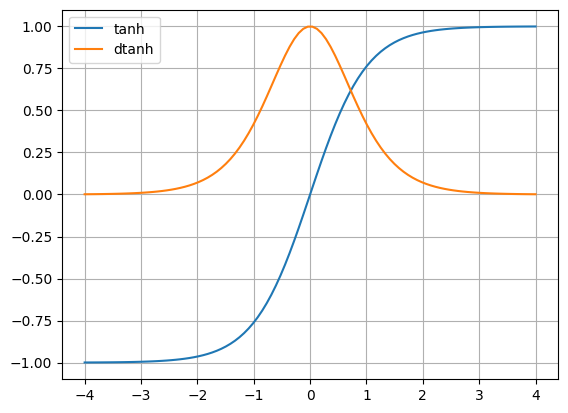

In [36]:
xs = np.linspace(-4, 4, 100)
ys = np.tanh(xs)
dtanh = 1 - np.tanh(xs)**2

plt.plot(xs, ys, label='tanh')
plt.plot(xs, dtanh, label='dtanh')
plt.legend()
plt.grid()

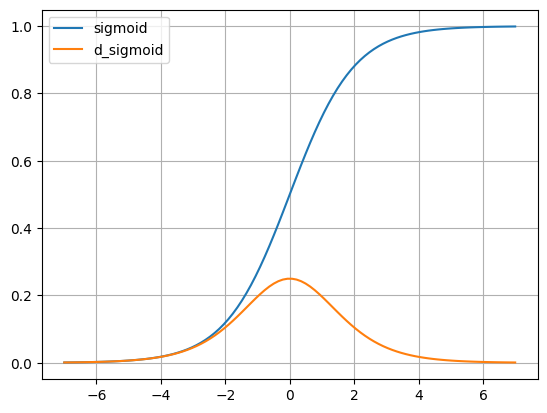

In [38]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

xs = np.linspace(-7, 7, 100)
ys = sigmoid(xs)
dsig = sigmoid(xs)*(1 - sigmoid(xs))

plt.plot(xs, ys, label='sigmoid')
plt.plot(xs, dsig, label='d_sigmoid')
plt.legend()
plt.grid()

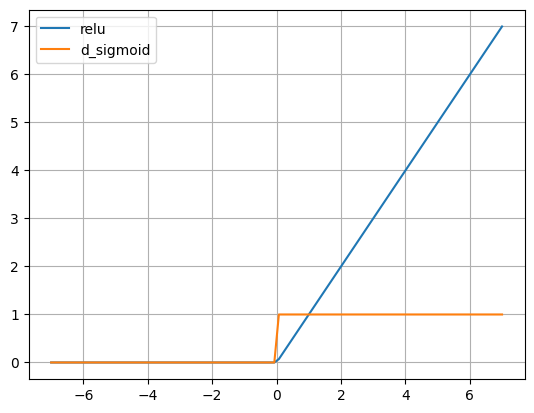

In [47]:
def relu(x):
    return np.maximum(0, x)

xs = np.linspace(-7, 7, 100)
ys = relu(xs)

d_relu = (xs > 0).astype(float)


plt.plot(xs, ys, label='relu')
plt.plot(xs, d_relu, label='d_sigmoid')
plt.legend()
plt.grid()